### Übung 7: Klassifikation

__Aufgabe 1__ ROC Kurve (10)

Angenommen Sie haben ein binäres Klassifizierungsproblem, für das Sie einen Klassifizierungsalgorithmus trainiert haben. 

__Hinweis:__ Die Berechnungen der Metriken sollen selbst implementiert werden. Es sollen also __keine__ Bibliotheken wie _scikit-learn_ etc. verwendet werden.

__a)__ Simulieren Sie je 100 Ergebnisse für einen
* perfekten Klassifizierer
* einen immer falschen Klassifizierer
* einen Klassifizierer, der nur rät (zieht Wahrsch. aus Gleichverteilung)
* einen Klassifizierer, mit guter Sensitivität, aber schlechter Spezifität

Hinweis: Damit eine Schwelle $t$   Sinn macht: Arbeiten Sie wie in der VL gezeigt mit **Wahrscheinlichkeiten**, die sich auch von 0 und 1 unterscheiden sollen!! (Auch für den perfekten Klassifizierer - verwenden Sie bitte Wahrscheinlichkeiten, die nicht alle exakt 0 oder 1 sind (auch wenn er dann nicht mehr ganz so perfekt ist ;))).

__b)__ Berechnen Sie für die Klassifizierer die Confusion-Matrix und folgende Kenngrößen, wobei Sie eine Klassifikationsschwelle von $t$=0,5 verwenden: 
* Sensitivität
* Spezifität
* Accuracy
* MCC
* F1-Score


In [2]:
import random
import math

random.seed(7)

n = 100
y_true = [0] * 50 + [1] * 50
random.shuffle(y_true)

perfect_scores = []
always_wrong_scores = []
random_scores = []
sensitive_scores = []

for label in y_true:
    if label == 1:
        perfect_scores.append(random.uniform(0.70, 0.95))
        always_wrong_scores.append(random.uniform(0.05, 0.30))
        sensitive_scores.append(random.uniform(0.55, 0.95))
    else:
        perfect_scores.append(random.uniform(0.05, 0.30))
        always_wrong_scores.append(random.uniform(0.70, 0.95))
        sensitive_scores.append(random.uniform(0.35, 0.85))
    random_scores.append(random.random())

classifiers = {
    "Perfekter Klassifizierer": perfect_scores,
    "Immer falscher Klassifizierer": always_wrong_scores,
    "Ratender Klassifizierer": random_scores,
    "Gute Sensitivitaet, schlechte Spezifitaet": sensitive_scores,
}

t = 0.5
metric_rows = []

for name, scores in classifiers.items():
    y_pred = []
    for score in scores:
        if score >= t:
            y_pred.append(1)
        else:
            y_pred.append(0)

    tp = fp = tn = fn = 0

    for i in range(len(y_true)):
        if y_true[i] == 1 and y_pred[i] == 1:
            tp += 1
        elif y_true[i] == 0 and y_pred[i] == 1:
            fp += 1
        elif y_true[i] == 0 and y_pred[i] == 0:
            tn += 1
        else:
            fn += 1

    sensitivitaet = tp / (tp + fn) if (tp + fn) > 0 else 0
    spezifitaet = tn / (tn + fp) if (tn + fp) > 0 else 0
    accuracy = (tp + tn) / len(y_true)

    mcc_nenner = math.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    if mcc_nenner > 0:
        mcc = (tp * tn - fp * fn) / mcc_nenner
    else:
        mcc = 0

    f1 = (2 * tp) / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0

    metric_rows.append([name, tp, fp, tn, fn, sensitivitaet, spezifitaet, accuracy, mcc, f1])

    print(name)
    print("Confusion Matrix bei t = 0.5")
    print("             vorhergesagt 1   vorhergesagt 0")
    print(f"tatsächlich 1      {tp:3d}              {fn:3d}")
    print(f"tatsächlich 0      {fp:3d}              {tn:3d}")
    print(f"Sensitivität: {sensitivitaet:.3f}")
    print(f"Spezifität:   {spezifitaet:.3f}")
    print(f"Accuracy:      {accuracy:.3f}")
    print(f"MCC:           {mcc:.3f}")
    print(f"F1-Score:      {f1:.3f}")
    print()


Perfekter Klassifizierer
Confusion Matrix bei t = 0.5
             vorhergesagt 1   vorhergesagt 0
tatsächlich 1       50                0
tatsächlich 0        0               50
Sensitivität: 1.000
Spezifität:   1.000
Accuracy:      1.000
MCC:           1.000
F1-Score:      1.000

Immer falscher Klassifizierer
Confusion Matrix bei t = 0.5
             vorhergesagt 1   vorhergesagt 0
tatsächlich 1        0               50
tatsächlich 0       50                0
Sensitivität: 0.000
Spezifität:   0.000
Accuracy:      0.000
MCC:           -1.000
F1-Score:      0.000

Ratender Klassifizierer
Confusion Matrix bei t = 0.5
             vorhergesagt 1   vorhergesagt 0
tatsächlich 1       29               21
tatsächlich 0       26               24
Sensitivität: 0.580
Spezifität:   0.480
Accuracy:      0.530
MCC:           0.060
F1-Score:      0.552

Gute Sensitivitaet, schlechte Spezifitaet
Confusion Matrix bei t = 0.5
             vorhergesagt 1   vorhergesagt 0
tatsächlich 1       50        

__c)__ Berechnen Sie für unterschiedliche Schwellen TPR und FPR und zeichnen Sie für jeden der Klassifikatoren die ROC-Kurve (ohne fertige Bibliotheken für ROC/AUC Kurven zu verwenden).

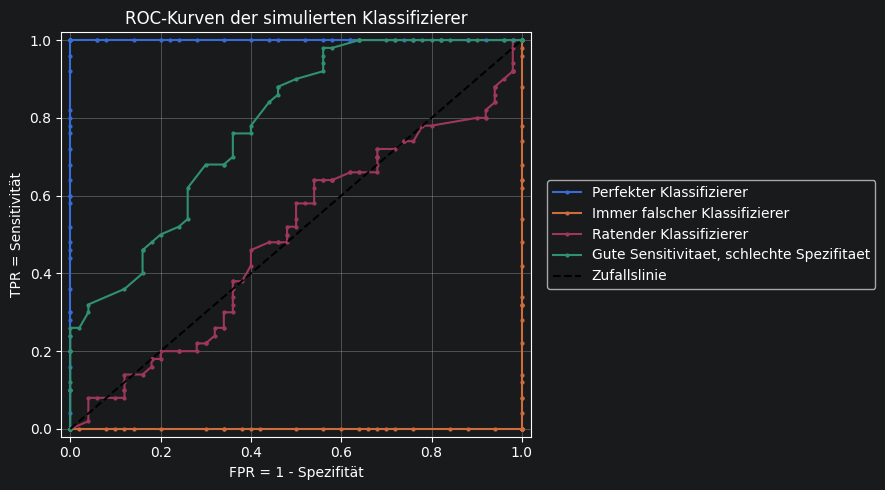

In [3]:
import matplotlib.pyplot as plt

schwellen = []
for i in range(100, -1, -1):
    schwellen.append(i / 100)

roc_points = {}

plt.figure(figsize=(9, 5))

for name, scores in classifiers.items():
    fpr_values = []
    tpr_values = []

    for schwelle in schwellen:
        y_pred = []
        for score in scores:
            if score >= schwelle:
                y_pred.append(1)
            else:
                y_pred.append(0)

        tp = fp = tn = fn = 0

        for i in range(len(y_true)):
            if y_true[i] == 1 and y_pred[i] == 1:
                tp += 1
            elif y_true[i] == 0 and y_pred[i] == 1:
                fp += 1
            elif y_true[i] == 0 and y_pred[i] == 0:
                tn += 1
            else:
                fn += 1

        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

        tpr_values.append(tpr)
        fpr_values.append(fpr)

    roc_points[name] = [fpr_values, tpr_values]
    plt.plot(fpr_values, tpr_values, marker="o", markersize=2, label=name)

plt.plot([0, 1], [0, 1], "k--", label="Zufallslinie")
plt.xlabel("FPR = 1 - Spezifität")
plt.ylabel("TPR = Sensitivität")
plt.title("ROC-Kurven der simulierten Klassifizierer")
plt.xlim(-0.02, 1.02)
plt.ylim(-0.02, 1.02)
plt.grid(True)
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()


__Aufgabe 2__  Eigener Klassifizierer (10)

Der Datensatz PSA enthält Die PSA-Werte von 370 Patienten mit der jeweiligen (vereinfachten) Diagnose: krank
oder gesund. (PSA:prostataspezifische Antigen)


Versuchen Sie mithilfe einer ROC einen vernünftigen PSA-Grenzwert zu ermitteln, ab dem eine Behandlung oder
zumindest eine weiterführende Diagnose durchgeführt werden sollte (Achtung: Behandlung heißt Operation
und Bestrahlung - also nichts, was man so zum Spaß macht! Auch die weiterführende Diagnose durch eine
Prostatabiopsie ist nicht lustig, sondern sehr gefährlich und sollte nicht unnötigerweise gemacht werden!).
Erstellen Sie eine aussagekräftige Visualisierung, die Ihnen hilft Ihre Entscheidung zu begründen bzw. zu verteidigen.
Beachten Sie, dass (theoretisch) ein PSA-Screening bei jedem Mann ab einem Alter von ca. 40 Jahren regelmäßig
gemacht werden sollte. Das wird deshalb in Deutschland jedes Jahr bei ca. 25 Mio Männern gemacht. Die
Inzidenz von Prostatakrebs (neu diagnostizierte Erkrankungen) beträgt ca. 70000 pro Jahr.(A.Dominik)

Sie können hier beliebige Bibliotheken verwenden.

__a)__ Visualisieren Sie hierfür zunächst die Daten, so dass Sie genauere Informationen über die Verteilungen erhalten.




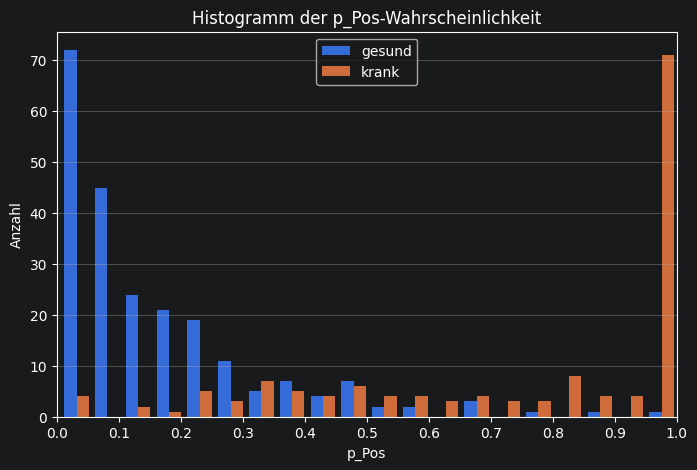

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression

psa = pd.read_csv("PSA.txt", sep="\t")
psa["krank_binary"] = (psa["Diagnose"] == "krank").astype(int)
psa["PSA_log"] = np.log1p(psa["PSA"])

modell = LogisticRegression()
modell.fit(psa[["PSA_log"]], psa["krank_binary"])
psa["p_Pos"] = modell.predict_proba(psa[["PSA_log"]])[:, 1]

gesund = psa.loc[psa["Diagnose"] == "gesund", "p_Pos"]
krank = psa.loc[psa["Diagnose"] == "krank", "p_Pos"]

plt.figure(figsize=(8, 5))
plt.hist([gesund, krank], bins=20, label=["gesund", "krank"])
plt.xlabel("p_Pos")
plt.ylabel("Anzahl")
plt.title("Histogramm der p_Pos-Wahrscheinlichkeit")
plt.xlim(0, 1)
plt.xticks([i / 10 for i in range(11)])
plt.grid(True, axis="y")
plt.legend()
plt.show()


__b)__ Wie viele kranke und wie viele gesunde Menschen befinden sich in Ihrem Datensatz?


In [7]:
anzahl_diagnosen = psa["Diagnose"].value_counts()
print(anzahl_diagnosen)



Diagnose
gesund    225
krank     145
Name: count, dtype: int64


__c)__ Verwenden Sie unterschiedliche PSA-Grenzwerte und ermitteln Sie die ROC-Kurve (visualisieren Sie sie).

TPR = Sensitivität
FPR = Spezifität
    Schwelle   TP   FP   TN   FN    TPR    FPR  Spezifität
0      10000    0    0  225  145  0.000  0.000       1.000
1       5000   20    0  225  125  0.138  0.000       1.000
2       2000   30    0  225  115  0.207  0.000       1.000
3       1000   33    0  225  112  0.228  0.000       1.000
4        500   41    0  225  104  0.283  0.000       1.000
5        100   49    0  225   96  0.338  0.000       1.000
6         50   49    0  225   96  0.338  0.000       1.000
7         30   57    0  225   88  0.393  0.000       1.000
8         20   66    1  224   79  0.455  0.004       0.996
9         15   71    1  224   74  0.490  0.004       0.996
10        12   74    1  224   71  0.510  0.004       0.996
11        10   75    1  224   70  0.517  0.004       0.996
12         9   82    2  223   63  0.566  0.009       0.991
13         8   90    2  223   55  0.621  0.009       0.991
14         7   91    3  222   54  0.628  0.013       0.987
15         6   98   

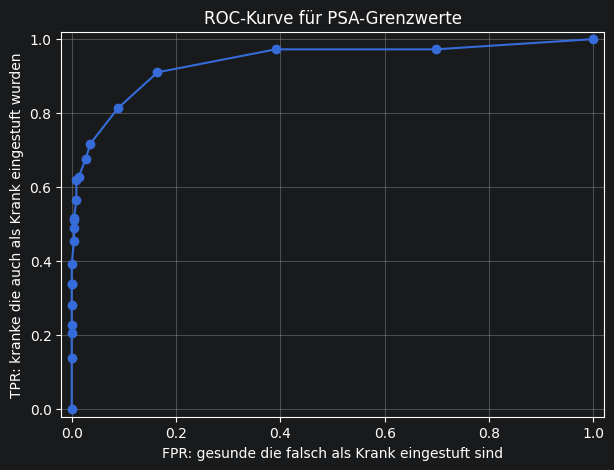

In [5]:
schwellen_psa = [10000, 5000, 2000, 1000, 500, 100, 50, 30, 20, 15, 12, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
roc_rows_psa = []

y_true_psa = psa["krank_binary"]

for schwelle in schwellen_psa:
    y_pred_psa = (psa["PSA"] >= schwelle).astype(int)

    tp = ((y_true_psa == 1) & (y_pred_psa == 1)).sum()
    fp = ((y_true_psa == 0) & (y_pred_psa == 1)).sum()
    tn = ((y_true_psa == 0) & (y_pred_psa == 0)).sum()
    fn = ((y_true_psa == 1) & (y_pred_psa == 0)).sum()

    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    spezifitaet = tn / (tn + fp) if (tn + fp) > 0 else 0

    roc_rows_psa.append([schwelle, tp, fp, tn, fn, tpr, fpr, spezifitaet])

roc_psa = pd.DataFrame(
    roc_rows_psa,
    columns=["Schwelle", "TP", "FP", "TN", "FN", "TPR", "FPR", "Spezifität"]
)

print("TPR = Sensitivität")
print("FPR = Spezifität")
print(roc_psa[["Schwelle", "TP", "FP", "TN", "FN", "TPR", "FPR", "Spezifität"]].round(3))

plt.figure(figsize=(7, 5))
plt.plot(roc_psa["FPR"], roc_psa["TPR"], marker="o")
plt.xlabel("FPR: gesunde die falsch als Krank eingestuft sind")
plt.ylabel("TPR: kranke die auch als Krank eingestuft wurden")
plt.title("ROC-Kurve für PSA-Grenzwerte")
plt.xlim(-0.02, 1.02)
plt.ylim(-0.02, 1.02)
plt.grid(True)
plt.show()


__d)__ Legen Sie einen geeigneten Grenzwert fest. Schreiben Sie dafür den Schwellwert an jeden Punkt in der ROC-Kurve und überlegen Sie was laut Aufgabenstellung der beste Wert wäre.


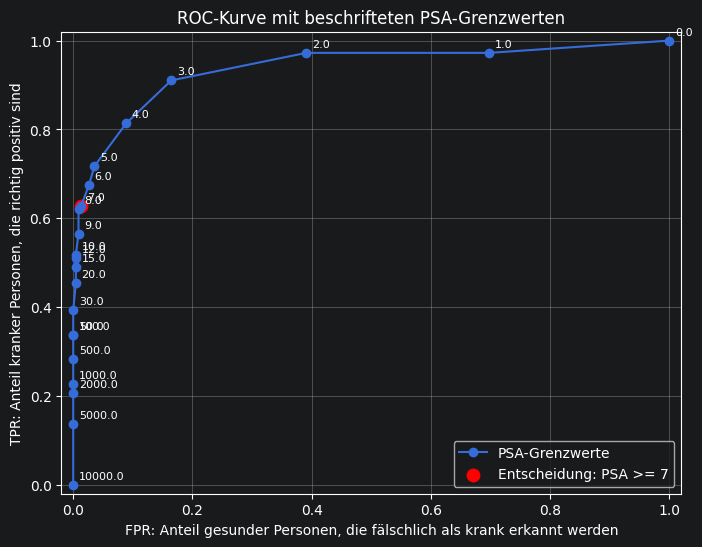

Ich wähle als Entscheidungskriterium PSA >= 7.
Begründung: Bei einem Screening mit sehr vielen gesunden Menschen sollten falsch positive Diagnosen möglichst niedrig bleiben.
Sensitivität: 0.628
Spezifität:   0.987
FPR:           0.013


In [7]:
entscheidungs_schwelle = 7
punkt = roc_psa[roc_psa["Schwelle"] == entscheidungs_schwelle].iloc[0]

plt.figure(figsize=(8, 6))
plt.plot(roc_psa["FPR"], roc_psa["TPR"], marker="o", label="PSA-Grenzwerte")

for i in range(len(roc_psa)):
    row = roc_psa.iloc[i]
    plt.annotate(
        str(row["Schwelle"]),
        (row["FPR"], row["TPR"]),
        textcoords="offset points",
        xytext=(4, 4),
        fontsize=8
    )

plt.scatter(
    punkt["FPR"],
    punkt["TPR"],
    color="red",
    s=80,
    label=f"Entscheidung: PSA >= {entscheidungs_schwelle}"
)

plt.xlabel("FPR: Anteil gesunder Personen, die fälschlich als krank erkannt werden")
plt.ylabel("TPR: Anteil kranker Personen, die richtig positiv sind")
plt.title("ROC-Kurve mit beschrifteten PSA-Grenzwerten")
plt.xlim(-0.02, 1.02)
plt.ylim(-0.02, 1.02)
plt.grid(True)
plt.legend()
plt.show()

print(f"Ich wähle als Entscheidungskriterium PSA >= {entscheidungs_schwelle}.")
print("Begründung: Bei einem Screening mit sehr vielen gesunden Menschen sollten falsch positive Diagnosen möglichst niedrig bleiben.")
print(f"Sensitivität: {punkt['TPR']:.3f}")
print(f"Spezifität:   {punkt['Spezifität']:.3f}")
print(f"FPR:           {punkt['FPR']:.3f}")

__e)__ Der Youden-Index ist ein Wert, der hilft in der ROC-Kurve den optimalen Schwellenwert zu finden. Dabei ist der optimale Schwellenwert der Wert, der dem maximalen Youden-Index zugeordnet werden kann. 

Der Youden-Index $J$ ist wie folgt definiert:

$J=Sensitivität+Spezifität -1$

Die Spezifität ist die $TNR$, die Sensitivität die $TPR$. Es gilt $FPR=1-TNR$. Für die Aufgaben müssen Sie keine neuen Kenngrößen berechnen, Sie können mit der gegebenen Hilfestellung $J$ durch $TPR$ und $FPR$ berechnen.

Bester Schwellenwert nach Youden-Index:
Schwelle: 3.41
Youden-Index: 0.754
Sensitivitaet: 0.897
FPR: 0.142
Spezifitaet: 0.858


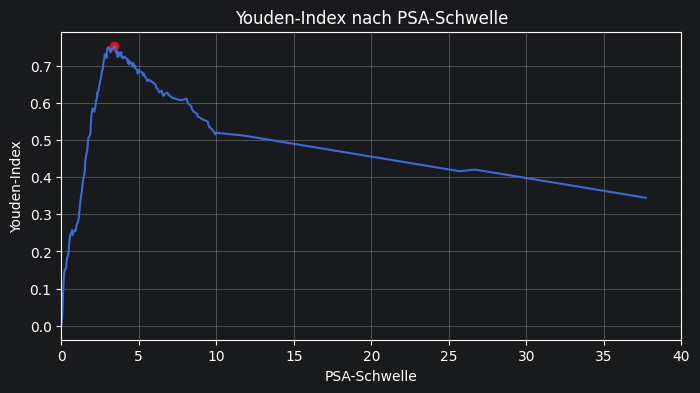

In [24]:
alle_schwellen = sorted(set(psa["PSA"].tolist() + [0, psa["PSA"].max() + 1]), reverse=True)
youden_rows = []

for schwelle in alle_schwellen:
    y_pred_psa = (psa["PSA"] >= schwelle).astype(int)

    tp = ((y_true_psa == 1) & (y_pred_psa == 1)).sum()
    fp = ((y_true_psa == 0) & (y_pred_psa == 1)).sum()
    tn = ((y_true_psa == 0) & (y_pred_psa == 0)).sum()
    fn = ((y_true_psa == 1) & (y_pred_psa == 0)).sum()

    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    youden_index = tpr - fpr
    #spezifitaet = 1 - fpr
    #youden_index = tpr + spezifitaet - 1

    youden_rows.append([schwelle, tp, fp, tn, fn, tpr, fpr, youden_index])

youden_df = pd.DataFrame(
    youden_rows,
    columns=["Schwelle", "TP", "FP", "TN", "FN", "TPR", "FPR", "Youden"]
)

beste_youden_zeile = youden_df.loc[youden_df["Youden"].idxmax()]

print("Bester Schwellenwert nach Youden-Index:")
print(f"Schwelle: {beste_youden_zeile['Schwelle']:.2f}")
print(f"Youden-Index: {beste_youden_zeile['Youden']:.3f}")
print(f"Sensitivitaet: {beste_youden_zeile['TPR']:.3f}")
print(f"FPR: {beste_youden_zeile['FPR']:.3f}")
print(f"Spezifitaet: {1 - beste_youden_zeile['FPR']:.3f}")

youden_plot = youden_df[youden_df["Schwelle"] <= 40].sort_values("Schwelle")

plt.figure(figsize=(8, 4))
plt.plot(youden_plot["Schwelle"], youden_plot["Youden"])
plt.scatter(beste_youden_zeile["Schwelle"], beste_youden_zeile["Youden"], color="red")
plt.xlim(0, 40)
plt.xticks(range(0, 41, 5))
plt.ticklabel_format(style="plain", axis="x")
plt.xlabel("PSA-Schwelle")
plt.ylabel("Youden-Index")
plt.title("Youden-Index nach PSA-Schwelle")
plt.grid(True)
plt.show()


__f)__ Wie groß ist bei Ihrem Entscheidungskriterium die Gesamtzahl
  * Korrekt positiv Diagnostizierter?
  * Falsch positiv Diagnostizierter (die unnötigerweise zur Biopsie müssen)?
  * Korrekt negativ Diagnostizierter?
  * Falsch negativ Diagnostizierter (deren Krankheit nicht erkannt wird)?

In [45]:
entscheidungs_schwelle = 7
y_pred_final = (psa["PSA"] >= entscheidungs_schwelle).astype(int)

tp = ((y_true_psa == 1) & (y_pred_final == 1)).sum()
fp = ((y_true_psa == 0) & (y_pred_final == 1)).sum()
tn = ((y_true_psa == 0) & (y_pred_final == 0)).sum()
fn = ((y_true_psa == 1) & (y_pred_final == 0)).sum()

print(f"Entscheidungskriterium: PSA >= {entscheidungs_schwelle}")
print("Korrekt positiv Diagnostizierte:", tp)
print("Falsch positiv Diagnostizierte:", fp)
print("Korrekt negativ Diagnostizierte:", tn)
print("Falsch negativ Diagnostizierte:", fn)


Entscheidungskriterium: PSA >= 7
Korrekt positiv Diagnostizierte: 91
Falsch positiv Diagnostizierte: 3
Korrekt negativ Diagnostizierte: 222
Falsch negativ Diagnostizierte: 54
